In [23]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [7]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = PROJECT_ROOT / "data" / "raw"

df = pd.read_csv(DATA_RAW / "diabetic_data.csv")
df.shape

(101766, 50)

In [9]:
df.head(10)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,55842,84259809,Caucasian,Male,[60-70),?,3,1,2,4,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,63768,114882984,Caucasian,Male,[70-80),?,1,1,7,5,...,No,No,No,No,No,No,No,No,Yes,>30
8,12522,48330783,Caucasian,Female,[80-90),?,2,1,4,13,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),?,3,3,4,12,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [12]:
# Build the binary target
df['readmitted_30'] = (df['readmitted'] == '<30').astype(int)

print(df['readmitted'].value_counts())
print()
print(df['readmitted_30'].value_counts(normalize=True))


readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

readmitted_30
0    0.888401
1    0.111599
Name: proportion, dtype: float64


In [14]:
# Missingness check
# This dataset encodes missing values as the string '?', not as NaN, pandas
# won't flag this as null by default, so df.isnull().sum() would be wrong
missing_pct = (df == '?').sum().sort_values(ascending=False) / len(df)*100
missing_pct = missing_pct[missing_pct > 0]
print(missing_pct)

weight               96.858479
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64


In [17]:
# Check for repeated patients
# Same patient can show up multiple times (repeated hospitalization)
# This matters for how the train/test split is done later, splitting
# by row instead of by patient would let the same patient appear
# in both sets, which leaks information and makes the model have
# better results that it should
print("Total encounters:", df['encounter_id'].nunique())
print("Unique patients:", df['patient_nbr'].nunique())
print(df['patient_nbr'].value_counts().head(10))

Total encounters: 101766
Unique patients: 71518
patient_nbr
88785891    40
43140906    28
1660293     23
23199021    23
88227540    23
23643405    22
84428613    22
92709351    21
90609804    20
89472402    20
Name: count, dtype: int64


## A1C result and readmission risk

A1C (HbA1c) measures average blood glucose over the past 2–3 months, making it
the standard marker of how well-controlled a patient's diabetes is. This dataset
doesn't record it as a number — it's the category `A1Cresult`, with `None`
meaning no A1C test was ordered during this specific hospital stay (a clinical
decision, not a missing measurement). Before looking at readmission rates,
it's worth checking how often A1C is even tested during an inpatient
admission, since that itself is informative.

In [18]:
# How often is A1C tested at all, nd what does the distribution look like?
print(df['A1Cresult'].value_counts())
print()
print(df['A1Cresult'].value_counts(normalize=True)*100)

A1Cresult
>8      8216
Norm    4990
>7      3812
Name: count, dtype: int64

A1Cresult
>8      48.278294
Norm    29.321894
>7      22.399812
Name: proportion, dtype: float64


In [20]:
# dropna=False keeps missing values in the count instead of silently discarding them
print(df['A1Cresult'].isna().sum())
print()
print(df['A1Cresult'].value_counts(dropna=False))
print()
print(df['A1Cresult'].value_counts(dropna=False, normalize=True)*100)

84748

A1Cresult
NaN     84748
>8       8216
Norm     4990
>7       3812
Name: count, dtype: int64

A1Cresult
NaN     83.277322
>8       8.073423
Norm     4.903406
>7       3.745848
Name: proportion, dtype: float64


In [22]:
# Recode missing A1C as an explicit, readable category
df['A1Cresult_filled'] = df['A1Cresult'].fillna('Not Tested')

readmit_by_a1c = df.groupby('A1Cresult_filled')['readmitted_30'].mean()*100
print(readmit_by_a1c.sort_values(ascending=False))

A1Cresult_filled
Not Tested    11.423278
>7            10.047219
>8             9.870983
Norm           9.659319
Name: readmitted_30, dtype: float64


**Finding:** Contrary to the initial hypothesis, readmission rate does not increase
monotonically with A1C severity (`Not Tested`: 11.4%, `>7`: 10.0%, `>8`: 9.9%,
`Norm`: 9.7%). The spread is small (~1.75 points on an 11% base rate), so A1C
category alone is a weak signal in isolation. The more notable result is that
untested patients have the *highest* rate, suggesting whether A1C was ordered
at all may reflect care thoroughness or how central diabetes was to that
admission, rather than glycemic severity itself being strongly predictive here.

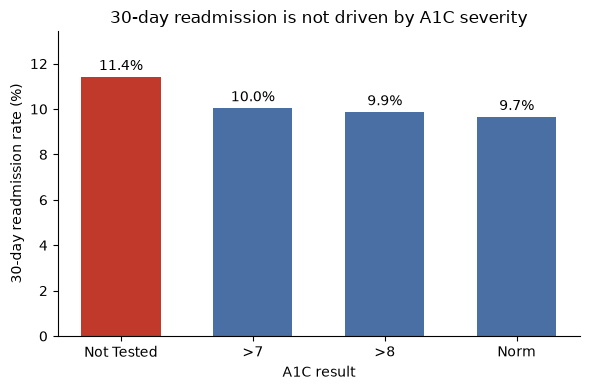

In [25]:
order = readmit_by_a1c.sort_values(ascending=False)
colors = ['#c0392b' if cat == 'Not Tested' else '#4a6fa5' for cat in order.index]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(order.index, order.values, color=colors, width=0.6)

for bar, value in zip(bars, order.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f'{value:.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('30-day readmission rate (%)')
ax.set_xlabel('A1C result')
ax.set_title('30-day readmission is not driven by A1C severity')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, max(order.values) + 2)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'figures' / 'readmission_by_a1c.png', dpi=150)
plt.show()

## Prior inpatient visits and readmission risk

`number_inpatient` counts how many times this patient was hospitalized as an
inpatient in the year before this encounter. Hypothesis: more prior admissions
signals a more severe or medically complex patient, so readmission risk should
increase with it, though whether that relationship is linear, accelerating, or
flattens out is worth checking rather than assuming.

Before grouping this into buckets for a readmission-rate comparison, it's worth
looking at the raw distribution first, it's likely heavily concentrated at 0,
which would break a naive equal-sized quantile split.

In [26]:
# Check the raw distribution before deciding how to bucket it
print(df['number_inpatient'].value_counts().sort_index())
print()
print(df['number_inpatient'].describe())

number_inpatient
0     67630
1     19521
2      7566
3      3411
4      1622
5       812
6       480
7       268
8       151
9       111
10       61
11       49
12       34
13       20
14       10
15        9
16        6
17        1
18        1
19        2
21        1
Name: count, dtype: int64

count    101766.000000
mean          0.635566
std           1.262863
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          21.000000
Name: number_inpatient, dtype: float64


In [28]:
# Bucket by where the data actually has volume, individual count for 0-2
# then a single 3+ group since higher counts too few patients to trust individually
def bucket_inpatient(n):
    if n >= 3:
        return '3+'
    return str(n)

df['number_inpatient_bucket'] = df['number_inpatient'].apply(bucket_inpatient)

order= ['0', '1', '2', '3+']
readmit_by_inpatient = df.groupby('number_inpatient_bucket')['readmitted_30'].mean().reindex(order)*100
print(readmit_by_inpatient)

number_inpatient_bucket
0      8.437084
1     12.924543
2     17.433254
3+    25.663215
Name: readmitted_30, dtype: float64


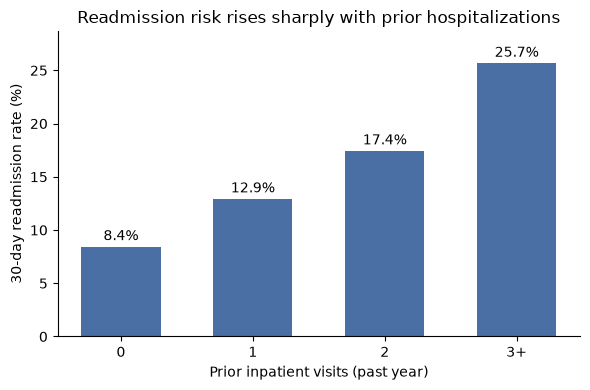

In [29]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(readmit_by_inpatient.index, readmit_by_inpatient.values, color='#4a6fa5', width=0.6)

for bar, value in zip(bars, readmit_by_inpatient.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{value:.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('30-day readmission rate (%)')
ax.set_xlabel('Prior inpatient visits (past year)')
ax.set_title('Readmission risk rises sharply with prior hospitalizations')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, max(readmit_by_inpatient.values) + 3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'figures' / 'readmission_by_prior_inpatient.png', dpi=150)
plt.show()

**Finding:** Readmission risk rises sharply and steadily with prior inpatient
visits, 8.4% with none, 12.9% with one, 17.4% with two, and 25.7% with three
or more (a ~3x range, the strongest single-variable relationship found so far).
The step sizes trend upward rather than flattening out, consistent with a
"frequent flyer" pattern where medical complexity compounds with repeated
hospitalizations, rather than patients managing their condition better with
more hospital exposure. Caveat: the `3+` group blends everyone from 3 to 21
prior visits into one bucket, so that final step isn't a clean like-for-like
increment the way the first two are, a patient with 3 prior visits and one
with 21 are counted together.